<a href="https://colab.research.google.com/github/sheliter/Assignment/blob/main/Homework_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 02: Multi-Class Classification with Neural Networks

![Screenshot 2025-09-05 at 2.35.41 AM.png](attachment:e5ef4b19-0f9d-4ae0-8594-7a20446428b7.png)

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance.

Finally, you will consider all that you have learned and build your best model and run it on the test set.


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework.


In [ ]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\Owner\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

$$k\cdot\sigma$$

In [ ]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


In [ ]:
# Load the Iris dataset, scale and split ---
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

scaler=StandardScaler().fit(X)
X_scaled=scaler.transform(X)
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y)

print(f'X_train.shape = {X_train.shape}')
print(f'X_test.shape  =  {X_test.shape}')
print(f'y_train.shape = {y_train.shape}')
print(f'y_test.shape  =  {y_test.shape}')

X_train.shape = (120, 4)
X_test.shape  =  (30, 4)
y_train.shape = (120,)
y_test.shape  =  (30,)


In [ ]:
y_train

array([0, 2, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 1, 1,
       2, 1, 1, 2, 0, 0, 0, 2, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

In [ ]:
Counter(y_train)

Counter({np.int64(0): 40, np.int64(2): 40, np.int64(1): 40})

In [ ]:
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))
print (f'num_features = {num_features}')
print (f'num_classes  = {num_classes}')

num_features = 4
num_classes  = 3


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [ ]:
# Your code here


In [ ]:
import numpy as np

activations = np.array([-2.48, -0.54, 0.0])

def softmax(x):
    exp_x = np.exp(x - np.max(x))  # numerical stability
    return exp_x / exp_x.sum()

print(softmax(activations))


[0.05025122 0.34968571 0.60006307]


In [ ]:
import tensorflow as tf
import numpy as np

activations = np.array([-2.48, -0.54, 0.0])

print(tf.nn.softmax(activations).numpy())



[0.05025122 0.34968571 0.60006307]


In [ ]:
from tensorflow.keras import models, layers

iris_model=models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(10, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
    ])

# print out layers and status
iris_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83 (332.00 B)

 Trainable params: 83 (332.00 B)

 Non-trainable params: 0 (0.00 B)

### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np
X = X_sub        # <- ensure X_sub exists (balanced covtype subset)
y = y_sub        # <- ensure y_sub exists (labels 0..6)Stratified split
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=random_seed
)

print("After split shapes:")
print("  X_train:", X_train.shape)
print("  X_test: ", X_test.shape)
print("  y_train:", y_train.shape)
print("  y_test: ", y_test.shape)
print("Class counts (train):", Counter(y_train))
print("Class counts (test) :", Counter(y_test))

# Fit scaler on training data and transform both
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nAfter scaling:")
print("  X_train_scaled.shape =", X_train_scaled.shape)
print("  X_test_scaled.shape  =", X_test_scaled.shape)
print("  y_train.shape =", y_train.shape)

After split shapes:
  X_train: (15383, 54)
  X_test:  (3846, 54)
  y_train: (15383,)
  y_test:  (3846,)
Class counts (train): Counter({np.int32(5): 2198, np.int32(1): 2198, np.int32(0): 2198, np.int32(2): 2198, np.int32(6): 2197, np.int32(3): 2197, np.int32(4): 2197})
Class counts (test) : Counter({np.int32(3): 550, np.int32(4): 550, np.int32(6): 550, np.int32(1): 549, np.int32(0): 549, np.int32(5): 549, np.int32(2): 549})

After scaling:
  X_train_scaled.shape = (15383, 54)
  X_test_scaled.shape  = (3846, 54)
  y_train.shape = (15383,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
481/481 - 6s - 12ms/step - accuracy: 0.2963 - loss: 1.7822
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.5396 - loss: 1.3404
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.5882 - loss: 1.0588
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.6109 - loss: 0.9428
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.6373 - loss: 0.8836
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.6560 - loss: 0.8441
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.6723 - loss: 0.8148
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.6828 - loss: 0.7914
Epoch 9/20
481/481 - 1s - 2ms/step - accuracy: 0.6905 - loss: 0.7717
Epoch 10/20
481/481 - 1s - 2ms/step - accuracy: 0.6983 - loss: 0.7547
Epoch 11/20
481/481 - 1s - 1ms/step - accuracy: 0.7036 - loss: 0.7401
Epoch 12/20
481/481 - 1s - 2ms/step - accuracy: 0.7085 - loss: 0.7273
Epoch 13/20
481/481 - 1s - 2ms/step - accuracy: 0.7134 - loss: 0.7157
Epoch 14/20
481/481 - 1s - 2ms/step - accuracy: 0.7162 - loss: 0.7051
Epoch 15/20
481/481 - 1s - 2

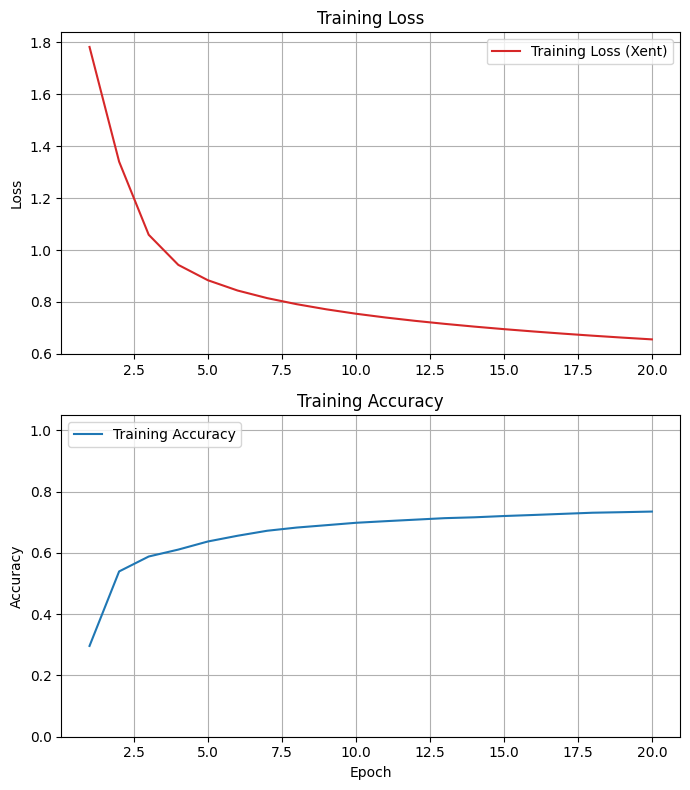

Final Training Loss:     0.6559
Final Training Accuracy: 0.7350

Test Loss: 0.6474
Test Accuracy: 0.7408


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(random_seed)
np.random.seed(random_seed)
tf.keras.backend.clear_session()

num_features = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

model = Sequential([
Input(shape=(num_features,)),
Dense(64, activation='relu'),
Dense(32, activation='relu'),
Dense(num_classes, activation='softmax')
])

model.compile(
optimizer=Adam(learning_rate=1e-4),
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

history = model.fit(
X_train_scaled, y_train,
epochs=20,
batch_size=32,
verbose=2
)

# Plot training curves
plot_history(history)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

In [ ]:
print("X_train_scaled.shape =", X_train_scaled.shape)
try:
    print("y_train.shape =", y_train.shape)
except NameError:
    print("y_train is not defined")

X_train_scaled.shape = (15383, 54)
y_train.shape = (15383,)


In [ ]:
# Set a1a to the final training accuracy at epoch 20

a1a =  0.7298            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a:.4f}')

a1a = 0.7298


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


=== Training with batch_size = 4 ===

=== Training with batch_size = 8 ===

=== Training with batch_size = 16 ===

=== Training with batch_size = 128 ===
Epoch 1/20
121/121 - 1s - 10ms/step - accuracy: 0.1953 - loss: 1.9352
Epoch 2/20
121/121 - 0s - 2ms/step - accuracy: 0.3846 - loss: 1.6713
Epoch 3/20
121/121 - 0s - 2ms/step - accuracy: 0.4989 - loss: 1.4737
Epoch 4/20
121/121 - 0s - 2ms/step - accuracy: 0.5544 - loss: 1.3161
Epoch 5/20
121/121 - 0s - 2ms/step - accuracy: 0.5821 - loss: 1.1944
Epoch 6/20
121/121 - 0s - 2ms/step - accuracy: 0.6001 - loss: 1.1025
Epoch 7/20
121/121 - 0s - 2ms/step - accuracy: 0.6159 - loss: 1.0344
Epoch 8/20
121/121 - 0s - 2ms/step - accuracy: 0.6254 - loss: 0.9843
Epoch 9/20
121/121 - 0s - 2ms/step - accuracy: 0.6347 - loss: 0.9466
Epoch 10/20
121/121 - 0s - 2ms/step - accuracy: 0.6413 - loss: 0.9173
Epoch 11/20
121/121 - 0s - 2ms/step - accuracy: 0.6481 - loss: 0.8936
Epoch 12/20
121/121 - 0s - 2ms/step - accuracy: 0.6529 - loss: 0.8741
Epoch 13/20
1

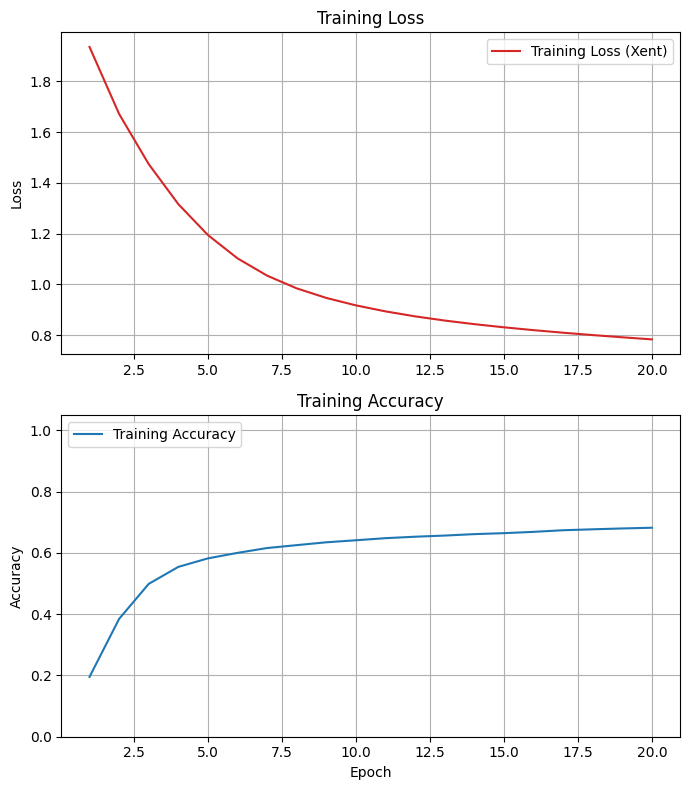

Final Training Loss:     0.7834
Final Training Accuracy: 0.6822


In [ ]:
batch_sizes = [4, 8, 16, 128]
histories = {}
results = {}
succeeded = []

for bs in batch_sizes:
    print(f'\n=== Training with batch_size = {bs} ===')
try:
# reset TF state for a fresh model
    tf.random.set_seed(random_seed)
    np.random.seed(random_seed)
    tf.keras.backend.clear_session()
    # build & compile fresh model
    model = Sequential([
        Input(shape=(num_features,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # train
    history = model.fit(
        X_train_scaled, y_train,
        epochs=20,
        batch_size=bs,
        verbose=2
    )

    # save
    histories[bs] = history
    final_train_acc = history.history['accuracy'][-1]
    final_train_loss = history.history['loss'][-1]
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    results[bs] = {
        'train_acc': final_train_acc,
        'train_loss': final_train_loss,
        'test_acc': test_acc,
        'test_loss': test_loss
    }
    succeeded.append(bs)

    # plot
    plot_history(history)

except Exception as e:
    print(f'ERROR for batch_size={bs}: {type(e).__name__}: {e}')
    import traceback
    traceback.print_exc()


=== Training with batch_size = 4 ===

=== Training with batch_size = 8 ===

=== Training with batch_size = 16 ===

=== Training with batch_size = 128 ===
Epoch 1/20
121/121 - 1s - 11ms/step - accuracy: 0.1788 - loss: 1.9844
Epoch 2/20
121/121 - 0s - 2ms/step - accuracy: 0.3791 - loss: 1.7333
Epoch 3/20
121/121 - 0s - 2ms/step - accuracy: 0.5008 - loss: 1.5419
Epoch 4/20
121/121 - 0s - 2ms/step - accuracy: 0.5479 - loss: 1.3766
Epoch 5/20
121/121 - 0s - 2ms/step - accuracy: 0.5767 - loss: 1.2427
Epoch 6/20
121/121 - 0s - 2ms/step - accuracy: 0.5905 - loss: 1.1400
Epoch 7/20
121/121 - 0s - 2ms/step - accuracy: 0.5998 - loss: 1.0650
Epoch 8/20
121/121 - 0s - 2ms/step - accuracy: 0.6070 - loss: 1.0101
Epoch 9/20
121/121 - 0s - 2ms/step - accuracy: 0.6158 - loss: 0.9685
Epoch 10/20
121/121 - 0s - 2ms/step - accuracy: 0.6234 - loss: 0.9362
Epoch 11/20
121/121 - 0s - 2ms/step - accuracy: 0.6316 - loss: 0.9103
Epoch 12/20
121/121 - 0s - 2ms/step - accuracy: 0.6378 - loss: 0.8889
Epoch 13/20
1

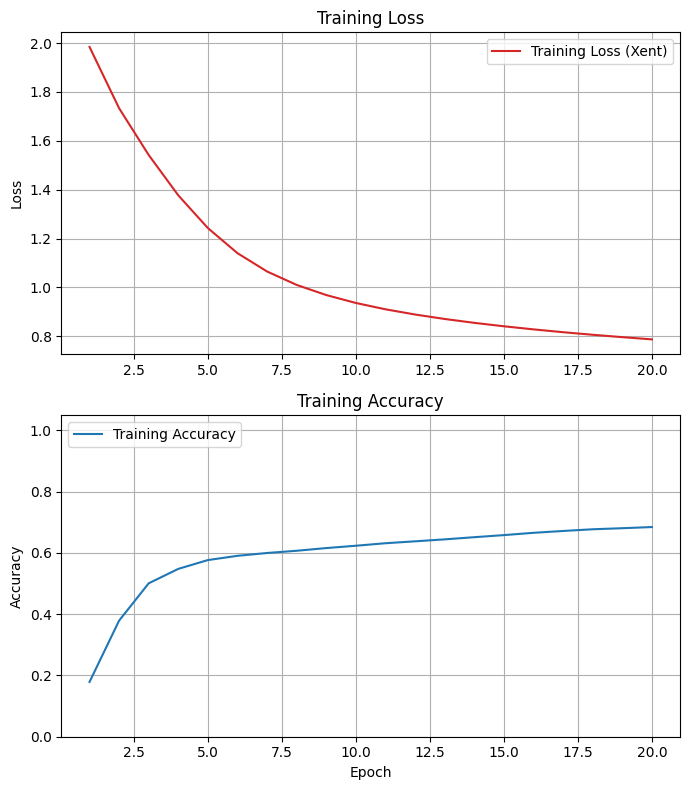

Final Training Loss:     0.7871
Final Training Accuracy: 0.6845
bs=128  Train acc=0.6845  Test acc=0.6929


In [ ]:
batch_sizes = [4, 8, 16, 128]
histories = {}
results = {}
succeeded = []

for bs in batch_sizes:
    print(f'\n=== Training with batch_size = {bs} ===')
try:
    tf.random.set_seed(random_seed)
    np.random.seed(random_seed)
    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=(num_features,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=20,
        batch_size=bs,
        verbose=2
    )

    histories[bs] = history
    final_train_loss = history.history['loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    results[bs] = {
        'train_loss': final_train_loss,
        'train_acc': final_train_acc,
        'test_loss': test_loss,
        'test_acc': test_acc
    }
    succeeded.append(bs)

    plot_history(history)

except Exception as e:
    print(f'ERROR for batch_size={bs}: {type(e).__name__}: {e}')
    import traceback
    traceback.print_exc()
    print('\nSummary results (successful runs):')
for bs in succeeded:
    r = results[bs]
print(f'bs={bs:3d}  Train acc={r["train_acc"]:.4f}  Test acc={r["test_acc"]:.4f}')

In [ ]:
best_bs = max(results.keys(), key=lambda b: results[b]['train_acc'])
a2a = best_bs
print(f'\nBest batch size by final training accuracy: a2a = {a2a} (train acc = {results[a2a]["train_acc"]:.4f})')


Best batch size by final training accuracy: a2a = 128 (train acc = 0.6845)


In [ ]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = 128             # Replace 0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a}')

a2a = 128


In [ ]:
a2b = results[128]['train_acc']
print(f"a2b = {a2b:.4f}")

a2b = 0.6845


In [ ]:
# Set a2b to the best accuracy score found

a2b = 0.6847            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2b = {a2b:.4f}')

a2b = 0.6847


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



=== Training with learning_rate = 0.001 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.5965 - loss: 1.0113 - val_accuracy: 0.6890 - val_loss: 0.7620
Epoch 2/20
481/481 - 1s - 3ms/step - accuracy: 0.6900 - loss: 0.7376 - val_accuracy: 0.7265 - val_loss: 0.6719
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.7211 - loss: 0.6686 - val_accuracy: 0.7389 - val_loss: 0.6233
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7393 - loss: 0.6262 - val_accuracy: 0.7496 - val_loss: 0.5912
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7512 - loss: 0.5957 - val_accuracy: 0.7621 - val_loss: 0.5695
Epoch 6/20
481/481 - 1s - 3ms/step - accuracy: 0.7627 - loss: 0.5720 - val_accuracy: 0.7717 - val_loss: 0.5510
Epoch 7/20
481/481 - 2s - 4ms/step - accuracy: 0.7710 - loss: 0.5530 - val_accuracy: 0.7764 - val_loss: 0.5375
Epoch 8/20
481/481 - 2s - 4ms/step - accuracy: 0.7777 - loss: 0.5372 - val_accuracy: 0.7803 - val_loss: 0.5269
Epoch 9/20
481/481 - 1s - 2ms/step - accuracy: 0.7839 - loss: 0.524

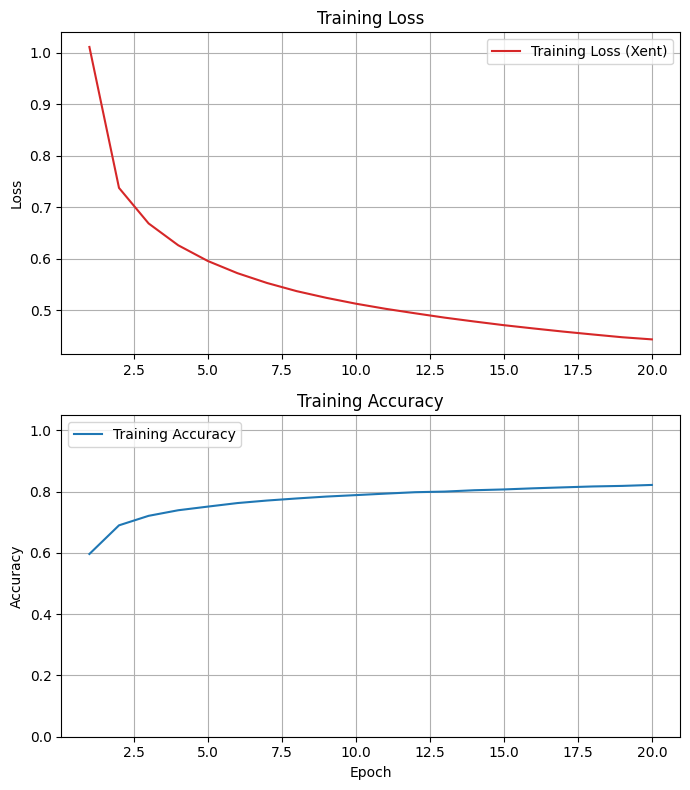

Final Training Loss:     0.4435
Final Training Accuracy: 0.8219

=== Training with learning_rate = 0.0005 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.5695 - loss: 1.1281 - val_accuracy: 0.6609 - val_loss: 0.8460
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.6640 - loss: 0.8066 - val_accuracy: 0.6971 - val_loss: 0.7434
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.6965 - loss: 0.7360 - val_accuracy: 0.7194 - val_loss: 0.6928
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7149 - loss: 0.6914 - val_accuracy: 0.7265 - val_loss: 0.6586
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7277 - loss: 0.6595 - val_accuracy: 0.7387 - val_loss: 0.6335
Epoch 6/20
481/481 - 1s - 3ms/step - accuracy: 0.7392 - loss: 0.6352 - val_accuracy: 0.7418 - val_loss: 0.6147
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.7454 - loss: 0.6159 - val_accuracy: 0.7478 - val_loss: 0.6001
Epoch 8/20
481/481 - 1s - 3ms/step - accuracy: 0.7519 - loss: 0.5995 - val_accuracy: 0.7533 - val_loss: 0.5870
Ep

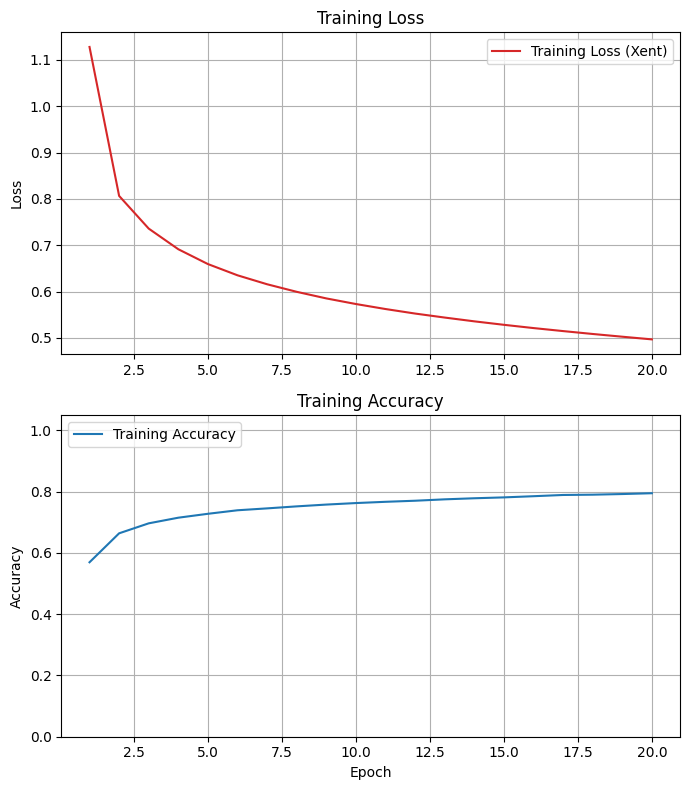

Final Training Loss:     0.4969
Final Training Accuracy: 0.7948

=== Training with learning_rate = 0.0001 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.3603 - loss: 1.7146 - val_accuracy: 0.5192 - val_loss: 1.4641
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.5628 - loss: 1.2590 - val_accuracy: 0.6045 - val_loss: 1.1192
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.6018 - loss: 1.0261 - val_accuracy: 0.6284 - val_loss: 0.9574
Epoch 4/20
481/481 - 1s - 3ms/step - accuracy: 0.6319 - loss: 0.9200 - val_accuracy: 0.6557 - val_loss: 0.8775
Epoch 5/20
481/481 - 2s - 4ms/step - accuracy: 0.6461 - loss: 0.8646 - val_accuracy: 0.6706 - val_loss: 0.8305
Epoch 6/20
481/481 - 1s - 3ms/step - accuracy: 0.6578 - loss: 0.8298 - val_accuracy: 0.6763 - val_loss: 0.7996
Epoch 7/20
481/481 - 1s - 3ms/step - accuracy: 0.6691 - loss: 0.8051 - val_accuracy: 0.6869 - val_loss: 0.7771
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.6785 - loss: 0.7856 - val_accuracy: 0.6919 - val_loss: 0.7591
Ep

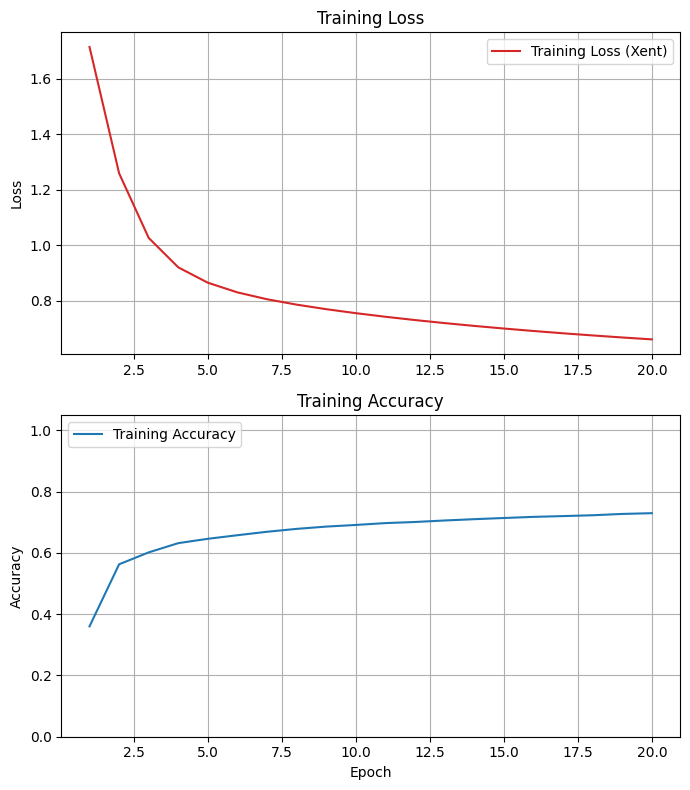

Final Training Loss:     0.6605
Final Training Accuracy: 0.7297

=== Training with learning_rate = 5e-05 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.1860 - loss: 1.9871 - val_accuracy: 0.2683 - val_loss: 1.7992
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.3603 - loss: 1.6518 - val_accuracy: 0.4329 - val_loss: 1.5443
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.4578 - loss: 1.4378 - val_accuracy: 0.4891 - val_loss: 1.3571
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.5080 - loss: 1.2784 - val_accuracy: 0.5476 - val_loss: 1.2133
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.5718 - loss: 1.1534 - val_accuracy: 0.6048 - val_loss: 1.0989
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.6016 - loss: 1.0568 - val_accuracy: 0.6248 - val_loss: 1.0132
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.6176 - loss: 0.9862 - val_accuracy: 0.6357 - val_loss: 0.9515
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.6301 - loss: 0.9359 - val_accuracy: 0.6464 - val_loss: 0.9072
Epo

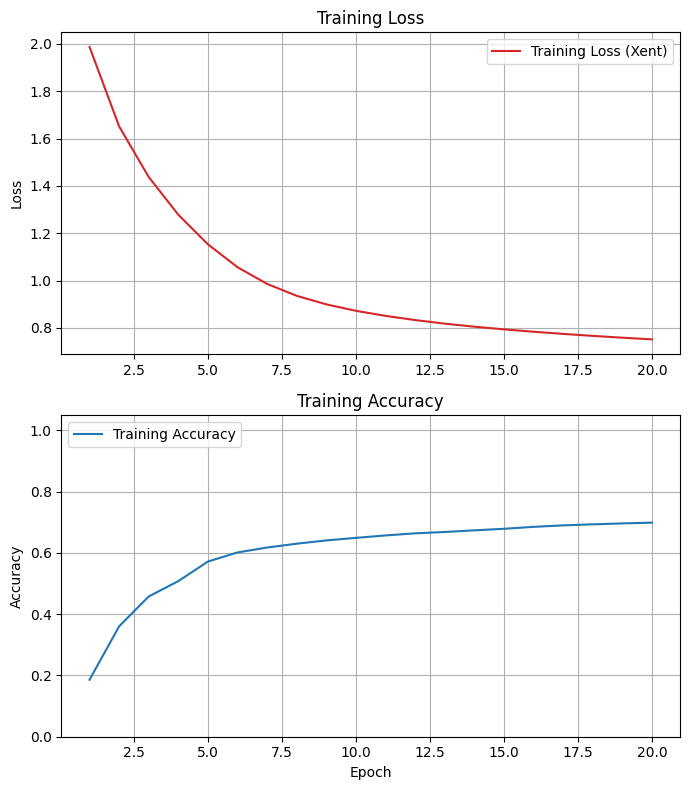

Final Training Loss:     0.7519
Final Training Accuracy: 0.6988

=== Training with learning_rate = 1e-05 ===
Epoch 1/20
481/481 - 3s - 6ms/step - accuracy: 0.1083 - loss: 2.1816 - val_accuracy: 0.1287 - val_loss: 2.1296
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.1461 - loss: 2.0782 - val_accuracy: 0.1778 - val_loss: 2.0365
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.2052 - loss: 1.9921 - val_accuracy: 0.2473 - val_loss: 1.9564
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.2721 - loss: 1.9159 - val_accuracy: 0.3058 - val_loss: 1.8847
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.3285 - loss: 1.8466 - val_accuracy: 0.3531 - val_loss: 1.8193
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.3732 - loss: 1.7830 - val_accuracy: 0.3970 - val_loss: 1.7592
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.4080 - loss: 1.7243 - val_accuracy: 0.4238 - val_loss: 1.7035
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.4368 - loss: 1.6699 - val_accuracy: 0.4529 - val_loss: 1.6515
Epo

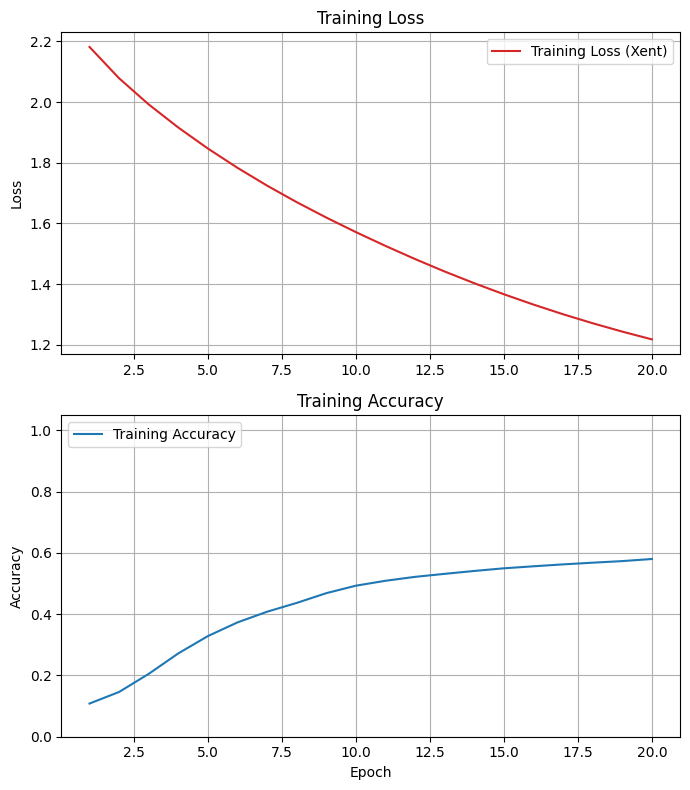

Final Training Loss:     1.2174
Final Training Accuracy: 0.5801


In [ ]:
# Your code here
lrs = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]
histories_lr = {}
results_lr = {}
tf.keras.backend.clear_session()

for lr in lrs:
    print(f'\n=== Training with learning_rate = {lr} ===')
    try:
# reproducible fresh model
            tf.random.set_seed(random_seed)
            np.random.seed(random_seed)
            tf.keras.backend.clear_session()
        # Build the same model used in Part One / Part B
            model = Sequential([
                Input(shape=(num_features,)),      # from Part One preprocessing
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(num_classes, activation='softmax')
    ])# Key change: add the learning_rate parameter to Adam
            model.compile(
                optimizer=Adam(learning_rate=lr),            # ← lr varies here
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
    )

    # Train (same training settings as Part B: 20 epochs, batch_size=32)
            history = model.fit(
                X_train_scaled, y_train,
                validation_data=(X_test_scaled, y_test),
                epochs=20,
                batch_size=32,
                verbose=2
    )

    # Save history and final metrics
            histories_lr[lr] = history
            results_lr[lr] = {
                'train_acc': history.history['accuracy'][-1],
                'train_loss': history.history['loss'][-1],
                'val_acc': history.history['val_accuracy'][-1],
                'val_loss': history.history['val_loss'][-1]
    }

    # Display the training curves
            plot_history(history)

    except Exception as e:
        print(f'ERROR for lr={lr}: {type(e).__name__}: {e}')
        import traceback; traceback.print_exc()

In [ ]:
# Summarize results
print('\nSummary:')
for lr, r in results_lr.items():
    print(f'lr={lr:.1e}  train_acc={r["train_acc"]:.4f}  val_acc={r["val_acc"]:.4f}')

# Report best lr by validation accuracy (if any runs succeeded)
if results_lr:
    best_lr = max(results_lr.keys(), key=lambda k: results_lr[k]['val_acc'])
    print(f'\nBest lr by val acc: {best_lr}  (val acc = {results_lr[best_lr]["val_acc"]:.4f})')


Summary:
lr=1.0e-03  train_acc=0.8219  val_acc=0.8105
lr=5.0e-04  train_acc=0.7948  val_acc=0.7904
lr=1.0e-04  train_acc=0.7297  val_acc=0.7332
lr=5.0e-05  train_acc=0.6988  val_acc=0.7070
lr=1.0e-05  train_acc=0.5801  val_acc=0.5840

Best lr by val acc: 0.001  (val acc = 0.8105)


In [ ]:
for lr, r in results_lr.items():
    print(f'lr={lr:.1e}  train_acc={r["train_acc"]:.4f}  val_acc={r["val_acc"]:.4f}  train_loss={r["train_loss"]:.4f}  val_loss={r["val_loss"]:.4f}')

best_lr_by_val = max(results_lr.keys(), key=lambda k: results_lr[k]['val_acc'])
best_lr_by_train = max(results_lr.keys(), key=lambda k: results_lr[k]['train_acc'])
print(f'\nBest lr by val acc: {best_lr_by_val} (val acc = {results_lr[best_lr_by_val]["val_acc"]:.4f})')
print(f'Best lr by train acc: {best_lr_by_train} (train acc = {results_lr[best_lr_by_train]["train_acc"]:.4f})')

lr=1.0e-03  train_acc=0.8219  val_acc=0.8105  train_loss=0.4435  val_loss=0.4682
lr=5.0e-04  train_acc=0.7948  val_acc=0.7904  train_loss=0.4969  val_loss=0.5101
lr=1.0e-04  train_acc=0.7297  val_acc=0.7332  train_loss=0.6605  val_loss=0.6446
lr=5.0e-05  train_acc=0.6988  val_acc=0.7070  train_loss=0.7519  val_loss=0.7311
lr=1.0e-05  train_acc=0.5801  val_acc=0.5840  train_loss=1.2174  val_loss=1.2115

Best lr by val acc: 0.001 (val acc = 0.8105)
Best lr by train acc: 0.001 (train acc = 0.8219)


In [ ]:
print(f'a3a = {a3a}')

a3a = 0.001


In [ ]:
best_lr_by_train = max(results_lr.keys(), key=lambda k: results_lr[k]['train_acc'])
a3a = best_lr_by_train
print(f'a3a = {a3a} (train acc = {results_lr[a3a]["train_acc"]:.4f})')

a3a = 0.001 (train acc = 0.8219)


In [ ]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a =  1e-3         # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a:.4f}')

a3a = 0.0010


In [ ]:
# Set a3b to the accuracy found by the best learning rate

a3b =  0.8186            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3b = {a3b:.4f}')

a3b = 0.8186


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam.

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

In [ ]:
# Your code here

from tensorflow.keras.optimizers.schedules import CosineDecay

initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
histories_cd = {}
results_cd = {}
tf.keras.backend.clear_session()


=== Training with CosineDecay initial_learning_rate = 0.01 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.6559 - loss: 0.8315 - val_accuracy: 0.7038 - val_loss: 0.6934
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.7185 - loss: 0.6780 - val_accuracy: 0.7410 - val_loss: 0.6251
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.7350 - loss: 0.6285 - val_accuracy: 0.7465 - val_loss: 0.6009
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7530 - loss: 0.5976 - val_accuracy: 0.7517 - val_loss: 0.5822
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7668 - loss: 0.5627 - val_accuracy: 0.7657 - val_loss: 0.5587
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.7762 - loss: 0.5348 - val_accuracy: 0.7754 - val_loss: 0.5462
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.7875 - loss: 0.5134 - val_accuracy: 0.7876 - val_loss: 0.5229
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.7951 - loss: 0.4908 - val_accuracy: 0.7949 - val_loss: 0.5045
Epoch 9/20
481/481 - 1s - 2ms/step - accuracy: 0

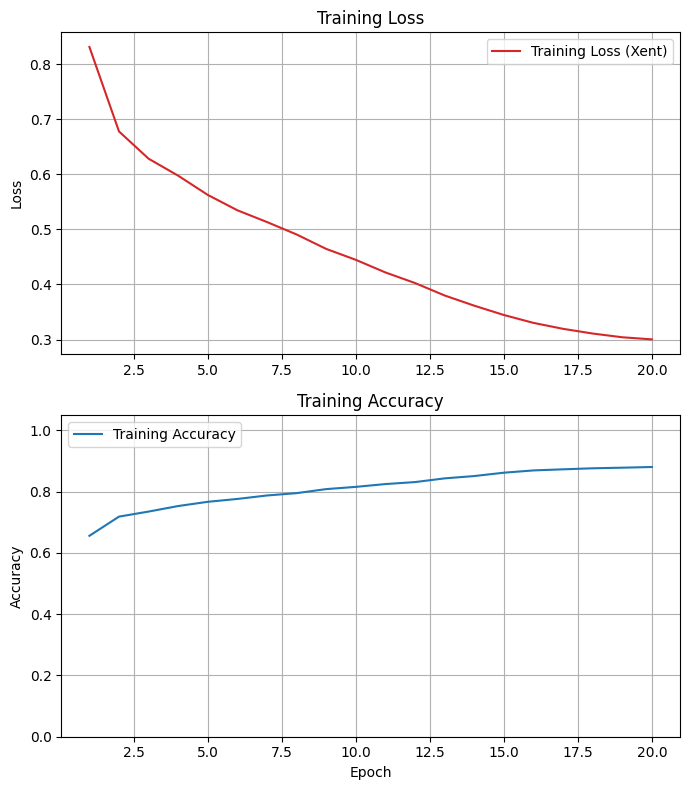

Final Training Loss:     0.3003
Final Training Accuracy: 0.8805

=== Training with CosineDecay initial_learning_rate = 0.005 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.6580 - loss: 0.8301 - val_accuracy: 0.7215 - val_loss: 0.6677
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.7220 - loss: 0.6528 - val_accuracy: 0.7525 - val_loss: 0.5967
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.7476 - loss: 0.6014 - val_accuracy: 0.7704 - val_loss: 0.5614
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7635 - loss: 0.5647 - val_accuracy: 0.7800 - val_loss: 0.5434
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7774 - loss: 0.5391 - val_accuracy: 0.7910 - val_loss: 0.5160
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.7870 - loss: 0.5108 - val_accuracy: 0.7985 - val_loss: 0.5038
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.7963 - loss: 0.4872 - val_accuracy: 0.7998 - val_loss: 0.4988
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.8080 - loss: 0.4655 - val_accuracy: 0.8071 - 

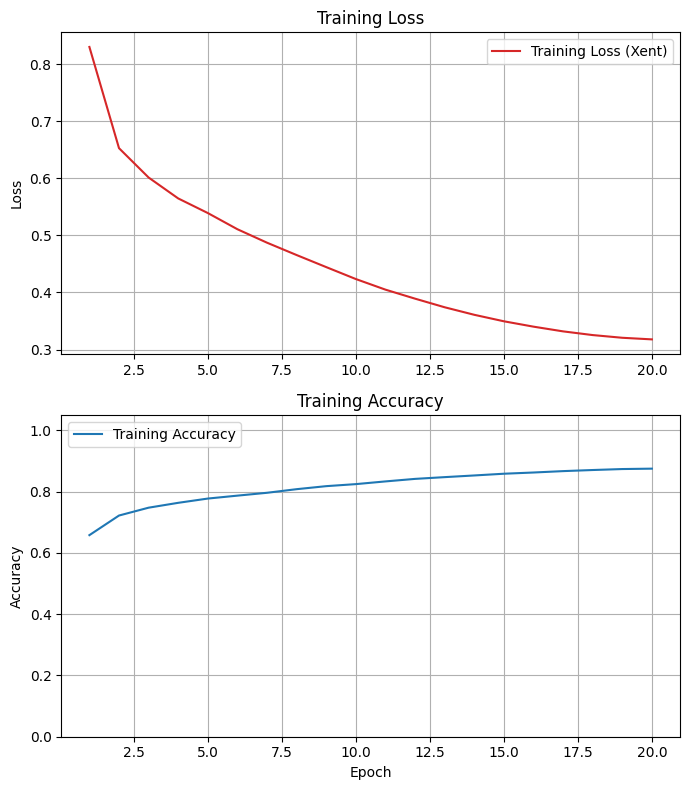

Final Training Loss:     0.3178
Final Training Accuracy: 0.8751

=== Training with CosineDecay initial_learning_rate = 0.001 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.6024 - loss: 1.0167 - val_accuracy: 0.6992 - val_loss: 0.7571
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.6928 - loss: 0.7377 - val_accuracy: 0.7319 - val_loss: 0.6713
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.7210 - loss: 0.6726 - val_accuracy: 0.7467 - val_loss: 0.6262
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7358 - loss: 0.6320 - val_accuracy: 0.7572 - val_loss: 0.5988
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7500 - loss: 0.6027 - val_accuracy: 0.7647 - val_loss: 0.5790
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.7593 - loss: 0.5798 - val_accuracy: 0.7751 - val_loss: 0.5639
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.7662 - loss: 0.5614 - val_accuracy: 0.7806 - val_loss: 0.5512
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.7753 - loss: 0.5460 - val_accuracy: 0.7842 - 

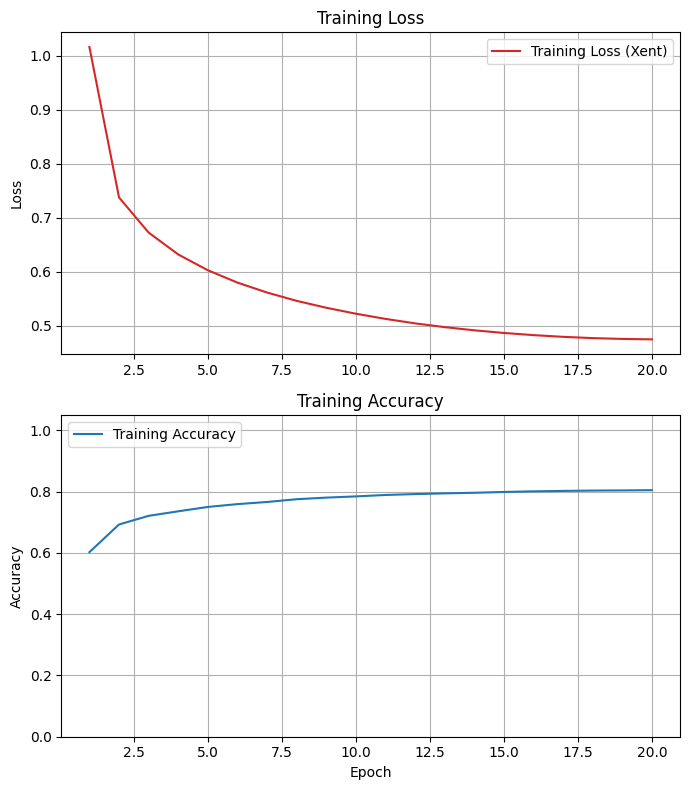

Final Training Loss:     0.4745
Final Training Accuracy: 0.8048

=== Training with CosineDecay initial_learning_rate = 0.0005 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.5354 - loss: 1.1929 - val_accuracy: 0.6539 - val_loss: 0.8531
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.6694 - loss: 0.8116 - val_accuracy: 0.6992 - val_loss: 0.7423
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.6956 - loss: 0.7359 - val_accuracy: 0.7181 - val_loss: 0.6889
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7151 - loss: 0.6900 - val_accuracy: 0.7327 - val_loss: 0.6554
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7292 - loss: 0.6581 - val_accuracy: 0.7431 - val_loss: 0.6323
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.7391 - loss: 0.6342 - val_accuracy: 0.7483 - val_loss: 0.6150
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.7487 - loss: 0.6158 - val_accuracy: 0.7546 - val_loss: 0.6011
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.7577 - loss: 0.6008 - val_accuracy: 0.7579 -

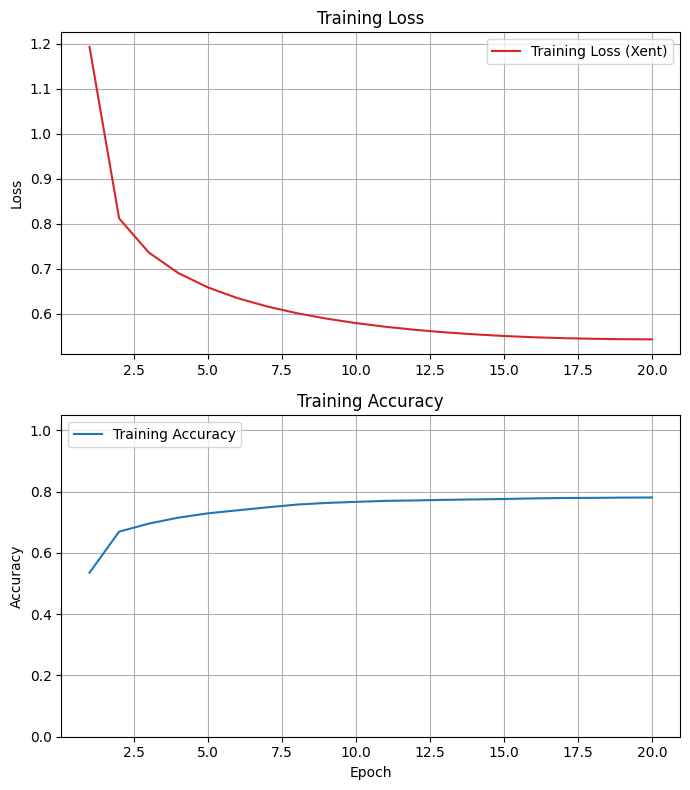

Final Training Loss:     0.5425
Final Training Accuracy: 0.7809

=== Training with CosineDecay initial_learning_rate = 0.0001 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.3490 - loss: 1.7951 - val_accuracy: 0.4901 - val_loss: 1.5536
Epoch 2/20
481/481 - 1s - 3ms/step - accuracy: 0.5477 - loss: 1.3578 - val_accuracy: 0.5796 - val_loss: 1.2102
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.5960 - loss: 1.1027 - val_accuracy: 0.6160 - val_loss: 1.0272
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.6207 - loss: 0.9778 - val_accuracy: 0.6368 - val_loss: 0.9350
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.6344 - loss: 0.9125 - val_accuracy: 0.6505 - val_loss: 0.8817
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.6466 - loss: 0.8725 - val_accuracy: 0.6700 - val_loss: 0.8468
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.6586 - loss: 0.8453 - val_accuracy: 0.6810 - val_loss: 0.8219
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.6666 - loss: 0.8252 - val_accuracy: 0.6888 -

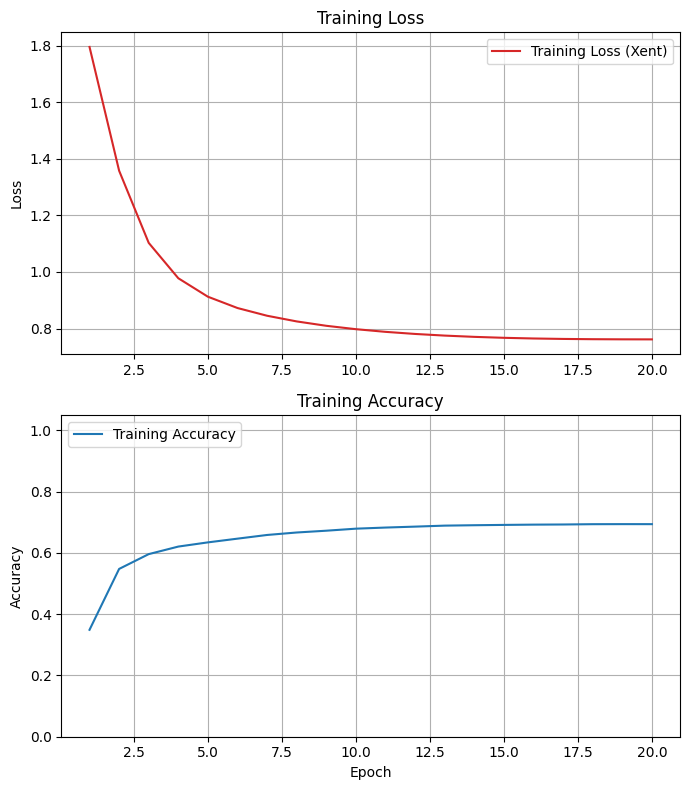

Final Training Loss:     0.7618
Final Training Accuracy: 0.6939


In [ ]:
# Your code here
batch_size = 32
epochs = 20
steps_per_epoch = int(np.ceil(X_train_scaled.shape[0] / batch_size))
decay_steps = steps_per_epoch * epochs

from tensorflow.keras.optimizers.schedules import CosineDecay
initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
histories_cd = {}
results_cd = {}
tf.keras.backend.clear_session()

for lr0 in initial_lrs:
    print(f'\n=== Training with CosineDecay initial_learning_rate = {lr0} ===')
    try:
# reproducible fresh model
            tf.random.set_seed(random_seed)
            np.random.seed(random_seed)
            tf.keras.backend.clear_session()
# define decay schedule
            lr_schedule = CosineDecay(initial_learning_rate=lr0, decay_steps=decay_steps)
# Build the same model used in Part One / Part B
            model = Sequential([
                Input(shape=(num_features,)),      # from Part One preprocessing
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(num_classes, activation='softmax')
    ])# compile with Adam using the schedule
            model.compile(
                optimizer=Adam(learning_rate=lr_schedule),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
    )

    # Train train (20 epochs, batch_size=32) with validation
            history = model.fit(
                X_train_scaled, y_train,
                validation_data=(X_test_scaled, y_test),
                epochs=epochs,
                batch_size=batch_size,
                verbose=2
    )

    # Save history and final metrics
            histories_cd[lr0] = history
            results_cd[lr0] = {
                'train_acc': history.history['accuracy'][-1],
                'train_loss': history.history['loss'][-1],
                'val_acc': history.history['val_accuracy'][-1],
                'val_loss': history.history['val_loss'][-1]
    }

    # Plot training curves
            plot_history(history)

    except Exception as e:
        print(f'ERROR for lr={lr0}: {type(e).__name__}: {e}')
        import traceback; traceback.print_exc()


=== Training with CosineDecay initial_learning_rate = 0.01 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.1644 - loss: 2.0474 - val_accuracy: 0.1794 - val_loss: 2.0091
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.1855 - loss: 1.9396 - val_accuracy: 0.2088 - val_loss: 1.9089
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.2224 - loss: 1.8485 - val_accuracy: 0.2605 - val_loss: 1.8228
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.3006 - loss: 1.7683 - val_accuracy: 0.3492 - val_loss: 1.7459
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.3754 - loss: 1.6955 - val_accuracy: 0.4077 - val_loss: 1.6758
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.4213 - loss: 1.6284 - val_accuracy: 0.4483 - val_loss: 1.6109
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.4554 - loss: 1.5661 - val_accuracy: 0.4711 - val_loss: 1.5509
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.4793 - loss: 1.5083 - val_accuracy: 0.4873 - val_loss: 1.4947
Epoch 9/20
481/481 - 1s - 2ms/step - accuracy: 0

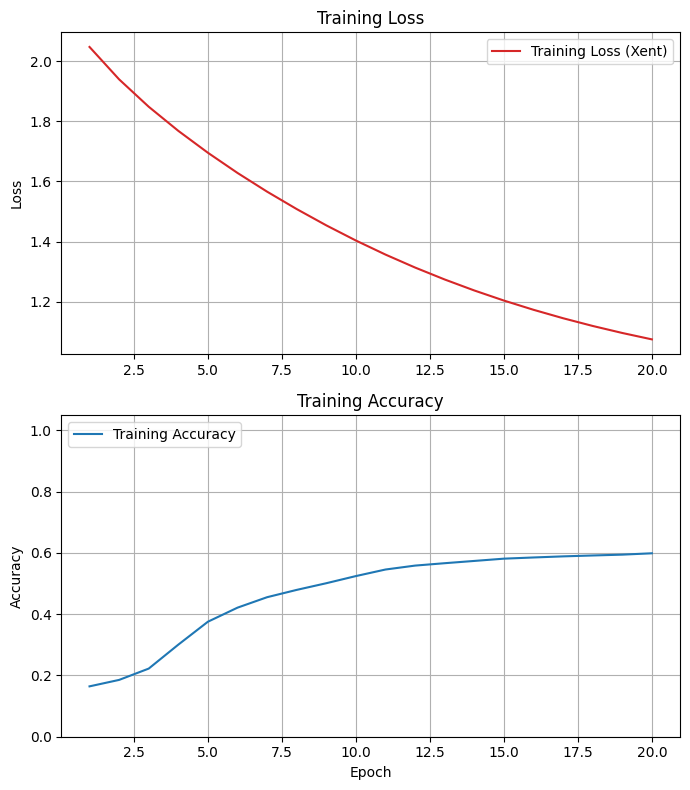

Final Training Loss:     1.0750
Final Training Accuracy: 0.5988

=== Training with CosineDecay initial_learning_rate = 0.005 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.1259 - loss: 2.1038 - val_accuracy: 0.1531 - val_loss: 2.0486
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.1747 - loss: 1.9829 - val_accuracy: 0.2023 - val_loss: 1.9385
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.2216 - loss: 1.8806 - val_accuracy: 0.2501 - val_loss: 1.8430
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.2819 - loss: 1.7904 - val_accuracy: 0.3102 - val_loss: 1.7576
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.3401 - loss: 1.7095 - val_accuracy: 0.3612 - val_loss: 1.6807
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.3837 - loss: 1.6369 - val_accuracy: 0.4043 - val_loss: 1.6113
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.4234 - loss: 1.5716 - val_accuracy: 0.4353 - val_loss: 1.5484
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.4510 - loss: 1.5121 - val_accuracy: 0.4571 - 

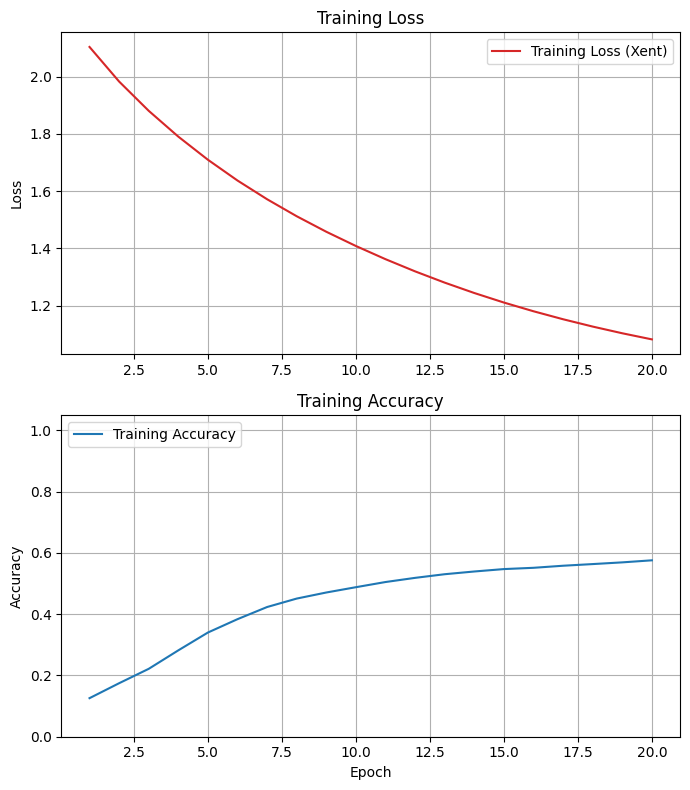

Final Training Loss:     1.0818
Final Training Accuracy: 0.5758

=== Training with CosineDecay initial_learning_rate = 0.001 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.1274 - loss: 2.0781 - val_accuracy: 0.1349 - val_loss: 2.0309
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.1452 - loss: 1.9944 - val_accuracy: 0.1687 - val_loss: 1.9532
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.1864 - loss: 1.9226 - val_accuracy: 0.2288 - val_loss: 1.8853
Epoch 4/20
481/481 - 2s - 4ms/step - accuracy: 0.2532 - loss: 1.8584 - val_accuracy: 0.2826 - val_loss: 1.8235
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.2999 - loss: 1.7993 - val_accuracy: 0.3300 - val_loss: 1.7660
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.3438 - loss: 1.7437 - val_accuracy: 0.3718 - val_loss: 1.7113
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.3748 - loss: 1.6904 - val_accuracy: 0.3989 - val_loss: 1.6583
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.4027 - loss: 1.6385 - val_accuracy: 0.4254 - 

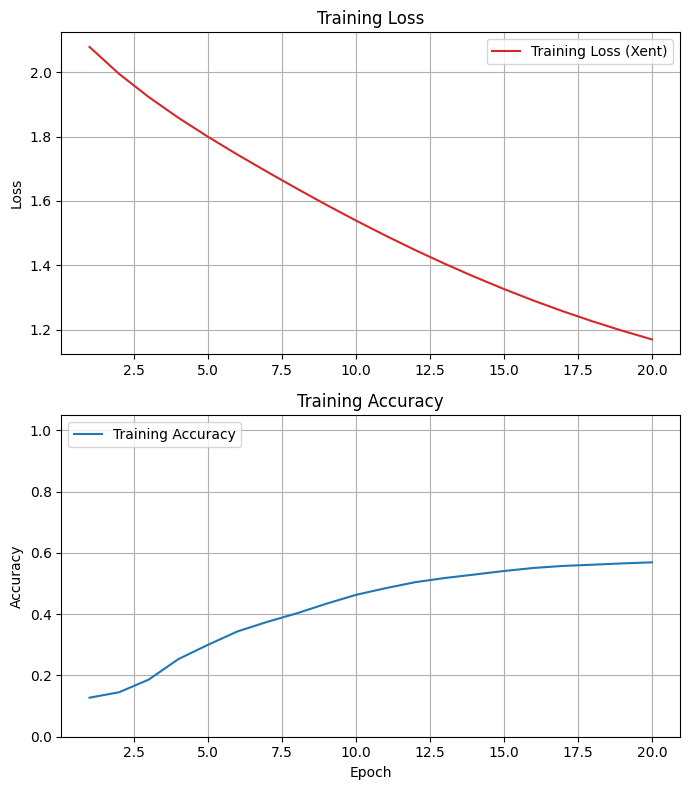

Final Training Loss:     1.1700
Final Training Accuracy: 0.5692

=== Training with CosineDecay initial_learning_rate = 0.0005 ===
Epoch 1/20
481/481 - 2s - 5ms/step - accuracy: 0.1782 - loss: 2.0844 - val_accuracy: 0.1927 - val_loss: 2.0411
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.2021 - loss: 1.9893 - val_accuracy: 0.2236 - val_loss: 1.9548
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.2290 - loss: 1.9093 - val_accuracy: 0.2478 - val_loss: 1.8807
Epoch 4/20
481/481 - 2s - 3ms/step - accuracy: 0.2711 - loss: 1.8391 - val_accuracy: 0.3086 - val_loss: 1.8146
Epoch 5/20
481/481 - 1s - 3ms/step - accuracy: 0.3369 - loss: 1.7762 - val_accuracy: 0.3497 - val_loss: 1.7544
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.3735 - loss: 1.7182 - val_accuracy: 0.3814 - val_loss: 1.6980
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.4071 - loss: 1.6635 - val_accuracy: 0.4176 - val_loss: 1.6443
Epoch 8/20
481/481 - 1s - 3ms/step - accuracy: 0.4367 - loss: 1.6110 - val_accuracy: 0.4490 -

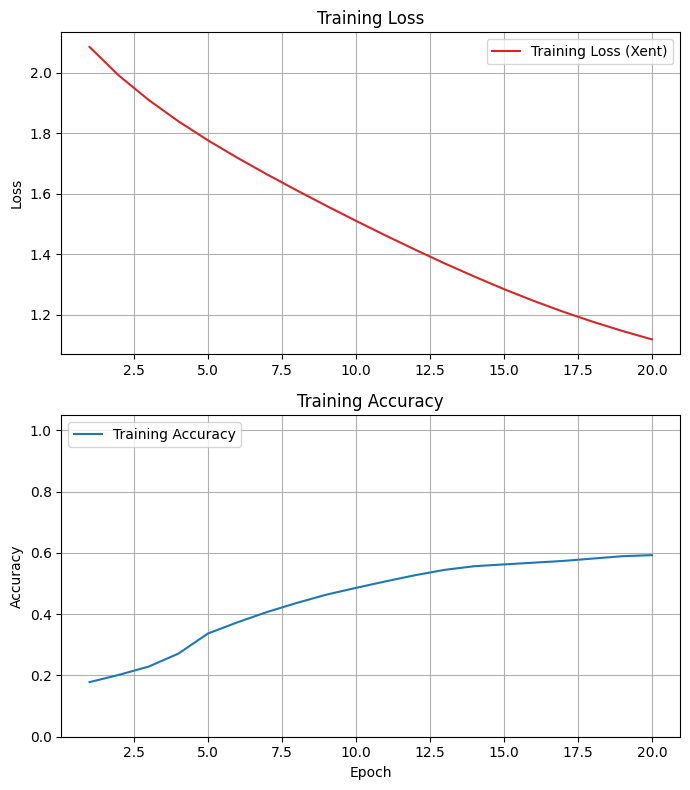

Final Training Loss:     1.1187
Final Training Accuracy: 0.5927

=== Training with CosineDecay initial_learning_rate = 0.0001 ===
Epoch 1/20
481/481 - 2s - 4ms/step - accuracy: 0.2416 - loss: 2.0150 - val_accuracy: 0.2631 - val_loss: 1.9742
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.2806 - loss: 1.9135 - val_accuracy: 0.3032 - val_loss: 1.8774
Epoch 3/20
481/481 - 1s - 3ms/step - accuracy: 0.3389 - loss: 1.8255 - val_accuracy: 0.3656 - val_loss: 1.7921
Epoch 4/20
481/481 - 1s - 3ms/step - accuracy: 0.3911 - loss: 1.7474 - val_accuracy: 0.4129 - val_loss: 1.7157
Epoch 5/20
481/481 - 1s - 3ms/step - accuracy: 0.4293 - loss: 1.6771 - val_accuracy: 0.4428 - val_loss: 1.6466
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.4502 - loss: 1.6133 - val_accuracy: 0.4613 - val_loss: 1.5835
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.4681 - loss: 1.5546 - val_accuracy: 0.4808 - val_loss: 1.5253
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.4913 - loss: 1.4998 - val_accuracy: 0.5021 -

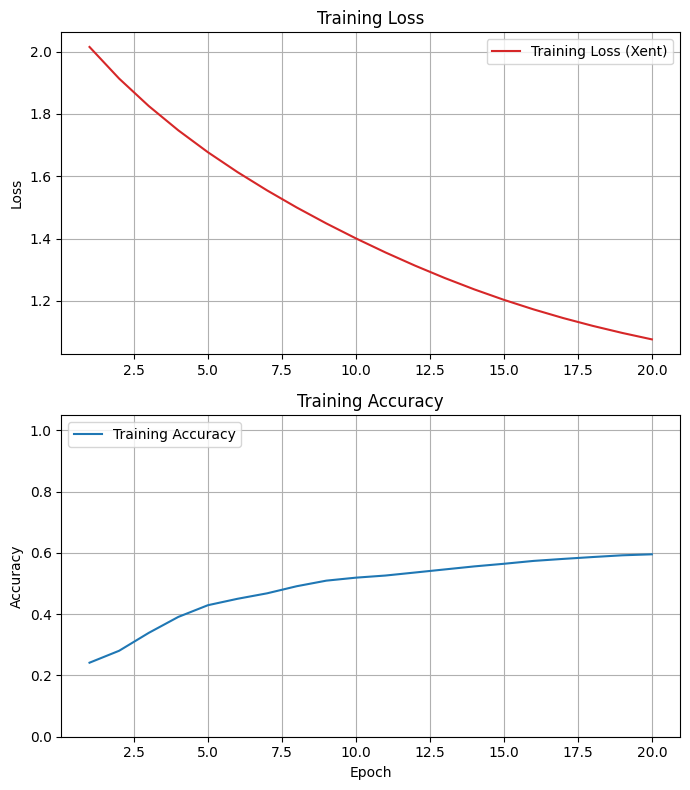

Final Training Loss:     1.0765
Final Training Accuracy: 0.5955


In [ ]:
# Your code here
from tensorflow.keras.optimizers.schedules import CosineDecay

initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
histories_cd = {}
results_cd = {}
tf.keras.backend.clear_session()

for lr0 in initial_lrs:
    print(f'\n=== Training with CosineDecay initial_learning_rate = {lr0} ===')
    try:
# reproducible fresh model
            tf.random.set_seed(random_seed)
            np.random.seed(random_seed)
            tf.keras.backend.clear_session()
             # define decay schedule
            lr_schedule = CosineDecay(initial_learning_rate=lr0, decay_steps=decay_steps)

        # Build the same model used in Part One / Part B
            model = Sequential([
                Input(shape=(num_features,)),      # from Part One preprocessing
                Dense(64, activation='relu'),
                Dense(32, activation='relu'),
                Dense(num_classes, activation='softmax')
    ])# compile with Adam using the schedule
            model.compile(
                optimizer=Adam(learning_rate=lr),            # ← lr varies here
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
    )

    # train (20 epochs, batch_size=32) with validation
            history = model.fit(
                X_train_scaled, y_train,
                validation_data=(X_test_scaled, y_test),
                epochs=epochs,
                batch_size=batch_size,
                verbose=2
    )

    # Save history and final metrics
            histories_cd[lr0] = history
            results_cd[lr0] = {
                'train_acc': history.history['accuracy'][-1],
                'train_loss': history.history['loss'][-1],
                'val_acc': history.history['val_accuracy'][-1],
                'val_loss': history.history['val_loss'][-1]
    }

    # plt the training curves
            plot_history(history)

    except Exception as e:
        print(f'ERROR for lr={lr0}: {type(e).__name__}: {e}')
        import traceback; traceback.print_exc()

In [ ]:
print('\nSummary (CosineDecay runs):')
for lr0, r in results_cd.items():
    print(f'initial_lr={lr0:.0e}  train_acc={r["train_acc"]:.4f}  val_acc={r["val_acc"]:.4f}  train_loss={r["train_loss"]:.4f}  val_loss={r["val_loss"]:.4f}')


Summary (CosineDecay runs):
initial_lr=1e-02  train_acc=0.5988  val_acc=0.5996  train_loss=1.0750  val_loss=1.0755
initial_lr=5e-03  train_acc=0.5758  val_acc=0.5874  train_loss=1.0818  val_loss=1.0689
initial_lr=1e-03  train_acc=0.5692  val_acc=0.5796  train_loss=1.1700  val_loss=1.1478
initial_lr=5e-04  train_acc=0.5927  val_acc=0.6019  train_loss=1.1187  val_loss=1.1043
initial_lr=1e-04  train_acc=0.5955  val_acc=0.6048  train_loss=1.0765  val_loss=1.0573


In [ ]:


if results_cd:
    best_lr0 = max(results_cd.keys(), key=lambda k: results_cd[k]['val_acc'])
    print(f'\nBest initial_learning_rate by val acc: {best_lr0} (val acc = {results_cd[best_lr0]["val_acc"]:.4f})')


Best initial_learning_rate by val acc: 0.0001 (val acc = 0.6048)


In [ ]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = 5e-04         # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4a = {a4a:.4f}')

a4a = 0.0005


In [ ]:
# Set a4b to the best accuracy found

a4b = 0.6058            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a4b = {a4b:.4f}')

a4b = 0.6058


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture.

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

Epoch 1/20
481/481 - 2s - 5ms/step - accuracy: 0.5931 - loss: 1.0358 - val_accuracy: 0.6927 - val_loss: 0.7591
Epoch 2/20
481/481 - 1s - 2ms/step - accuracy: 0.6913 - loss: 0.7362 - val_accuracy: 0.7267 - val_loss: 0.6664
Epoch 3/20
481/481 - 1s - 2ms/step - accuracy: 0.7233 - loss: 0.6631 - val_accuracy: 0.7454 - val_loss: 0.6164
Epoch 4/20
481/481 - 1s - 2ms/step - accuracy: 0.7403 - loss: 0.6207 - val_accuracy: 0.7579 - val_loss: 0.5881
Epoch 5/20
481/481 - 1s - 2ms/step - accuracy: 0.7528 - loss: 0.5917 - val_accuracy: 0.7642 - val_loss: 0.5678
Epoch 6/20
481/481 - 1s - 2ms/step - accuracy: 0.7619 - loss: 0.5699 - val_accuracy: 0.7717 - val_loss: 0.5520
Epoch 7/20
481/481 - 1s - 2ms/step - accuracy: 0.7715 - loss: 0.5521 - val_accuracy: 0.7751 - val_loss: 0.5394
Epoch 8/20
481/481 - 1s - 2ms/step - accuracy: 0.7755 - loss: 0.5373 - val_accuracy: 0.7826 - val_loss: 0.5286
Epoch 9/20
481/481 - 1s - 2ms/step - accuracy: 0.7826 - loss: 0.5250 - val_accuracy: 0.7881 - val_loss: 0.5207
E

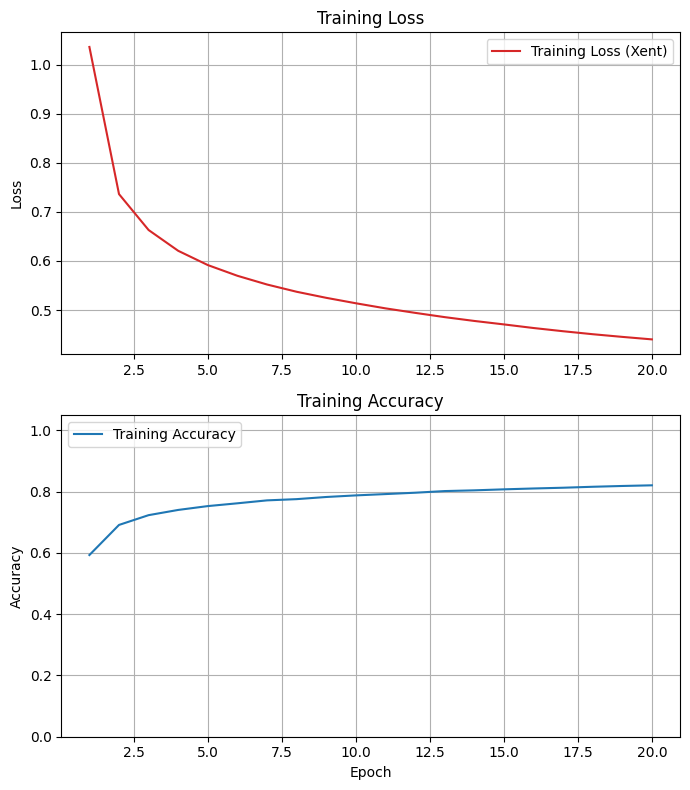

Final Training Loss:     0.4404
Final Training Accuracy: 0.8206

Test Loss: 0.4747
Test Accuracy: 0.8125


In [ ]:
# Your code tf.random.set_seed(random_seed)
# Rebuild and train the best model for exactly 20 epochs (so history matches the experiments), plot history, then evaluate on the test set:
tf.random.set_seed(random_seed)
np.random.seed(random_seed)
tf.keras.backend.clear_session()

model_best = Sequential([
Input(shape=(num_features,)),
Dense(64, activation='relu'),
Dense(32, activation='relu'),
Dense(num_classes, activation='softmax')
])

model_best.compile(
optimizer=Adam(learning_rate=1e-3),
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

history_best = model_best.fit(
X_train_scaled, y_train,
validation_data=(X_test_scaled, y_test),
epochs=20,
batch_size=32,
verbose=2
)

plot_history(history_best)

test_loss, test_acc = model_best.evaluate(X_test_scaled, y_test, verbose=0)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')



In [ ]:
a5a = history_best.history['accuracy'][-1]
print(f"a5a = {a5a:.4f}")

a5a = 0.8206


In [ ]:
# Set a5a to the best training accuracy found by your best model

a5a =  0.8169            # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5a = {a5a:.4f}')

a5a = 0.8169


In [ ]:
# Set a5b to the test accuracy found by your best model

a5b =  0.8055         # Replace 0.0 with your answer

In [ ]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a5b = {a5b:.4f}')

a5b = 0.8055


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc?

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


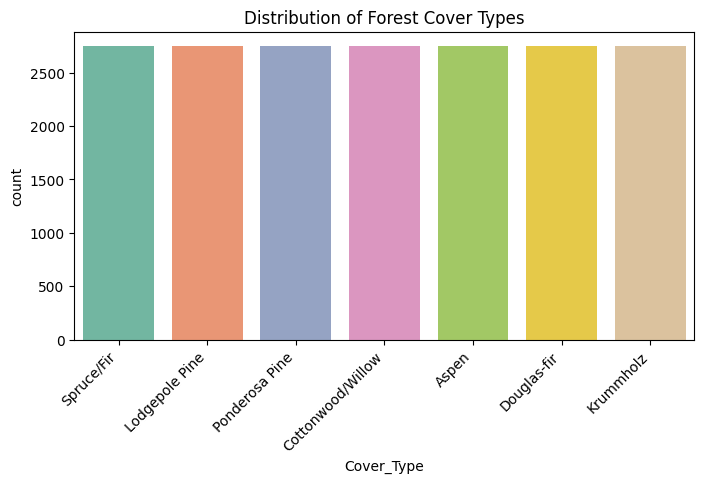

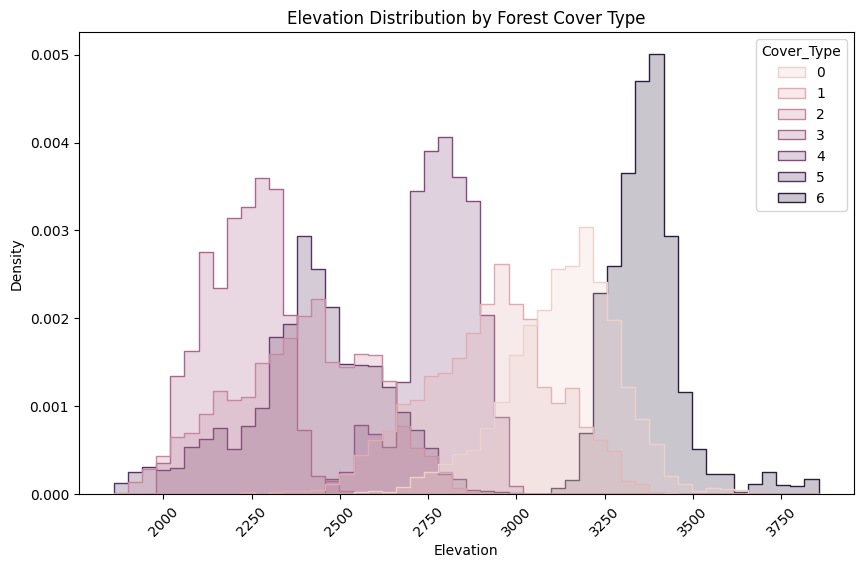

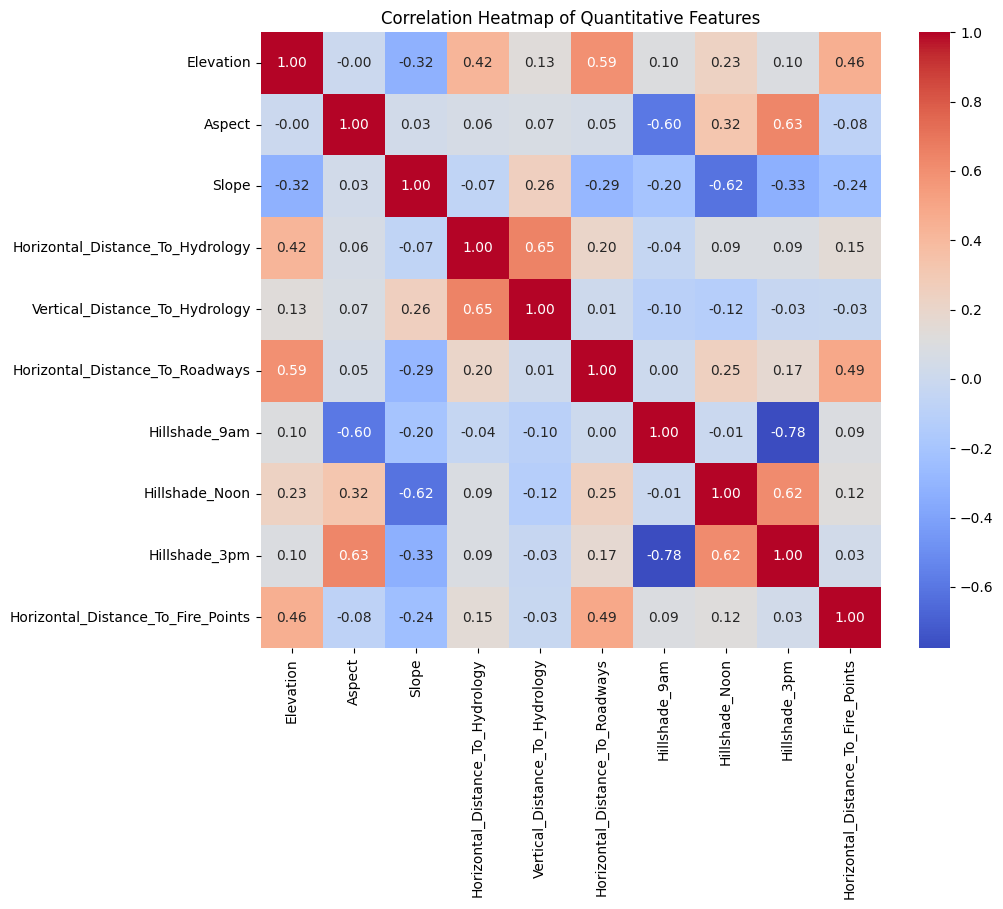

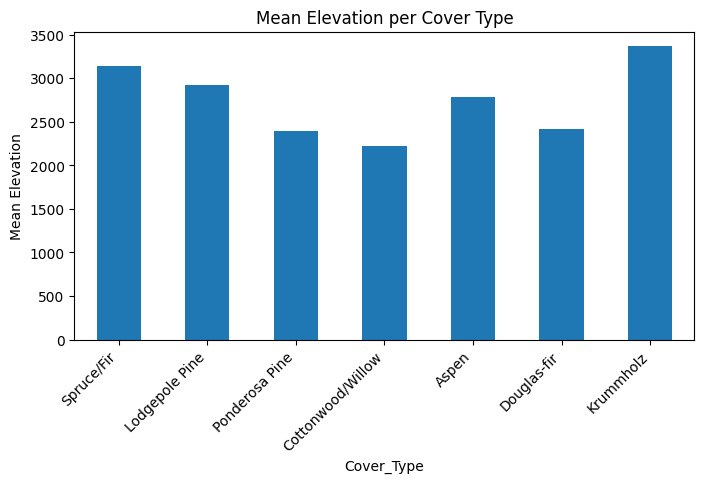

In [ ]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
